#### K-Means Clustering

K-Means Clustering technique is an unsupervised machine learning technique that helps in dividing the dataset into K number of clusters based on the similar input features.

#### Algorithm for K-Means Clustering

1.  Divide the dataset  into  K number of clusters based on the similar input features.

2.  Minimize the distance between the data points which are all present in the same clusters.

3.  Maximize the seperation between the clusters.

#### Problem Statement:----

We will build a complete Customer Segmentation Project using:

(a.)    Data Cleaning

(b.)    Exploratory Data Analysis

(c.)    Feature Scaling

(d.)    Elbow Method

(e.)    K-Means Clustering

(f.)    Cluster Visualization

(g.)    Cluster Interpretation


####    Step 1: Import all the necessary libraries

In [1]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection import train_test_split
from    sklearn.preprocessing   import StandardScaler, LabelEncoder
from    sklearn.cluster         import KMeans
from    sklearn.metrics         import accuracy_score, confusion_matrix, classification_report,precision_score,recall_score,f1_score,roc_auc_score

#### OBSERVATIONS:

1.  KMeans =============>  It is used for clustering algorithm and is used to divide the datasets into clusters.

####   Step 2: Load the dataset

In [2]:
#### Load the dataset

df = pd.read_csv("Mall_Customers_dataset.csv")

In [3]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### OBSERVATIONS:

1.  The above dataset explains about the details of each and every customer with their "AnnualIncome" and their "SpendingScore".

#### Step 3: Perform the Data Exploration

In [4]:
#### get the total length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 200


In [ ]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (200, 5)


In [6]:
#### get the first five rows of the dataset

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
#### get the last five rows of the dataset

df.tail()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [8]:
#### get the columns used in the dataset

df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [9]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [10]:
#### get the descriptive summary statistics about the columns used in the dataset

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### OBSERVATIONS:

1.  The above dataset explains about the descriptive statistical summary about each numerical column used in the dataset.

#### Step 4: Perform Data Cleaning and Feature Engineering

In [11]:
#### Replace the column name "Genre"  with "Gender"

df.rename(columns={"Genre":"Gender" ,
                   "Annual Income (k$)":"Annual_Income" ,
                   "Spending Score (1-100)" :   "Spending_Score"},inplace=True)

In [12]:
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### OBSERVATIONS:

1.  The column name "Genre" has been replaced with "Gender" in the dataset.

In [13]:
#### Remove an unnecessary column "CustomerID" from the dataset

df.drop(columns="CustomerID",axis=1,inplace=True)

In [14]:
df.head()

,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


#### OBSERVATIONS:

1.  The unnecessary column "CustomerID" has been removed from the dataset.

In [15]:
#### Check if there are any NULL Values in the dataset

df.isnull().sum()

Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [16]:
#### Check for any duplicate records in the dataset

df[df.duplicated()]

,Gender,Age,Annual_Income,Spending_Score


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

#### Step 5: Select the Relevant features

In [17]:
#### Select the relevant features from the dataset

X = df[["Annual_Income", "Spending_Score"]]

In [18]:
X

,Annual_Income,Spending_Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


#### OBSERVATIONS:

1.  The relevant features "Annual_Income" and "Spending_Score" were selected for clustering purpose.

#### Step 6: Perform the visualization based on the features selected

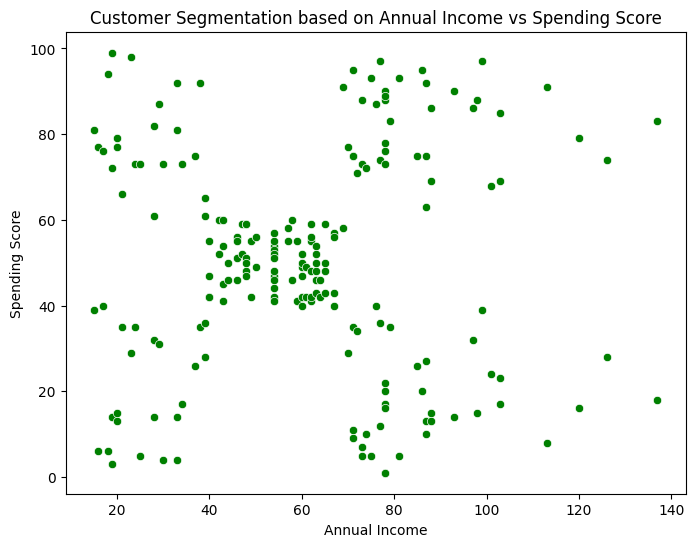

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Annual_Income',y='Spending_Score',data=X,color='green')
plt.title("Customer Segmentation based on Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

#### OBSERVATIONS:

1.  Scatter Plot has been performed on the Mall_Customers_dataset.csv and clusters have somewhat been formed based on its similar input features.

#### Step 7: Perform Feature Scaling on the inputs

In [20]:
from    sklearn.preprocessing   import  StandardScaler

#### create an object for Stanadrd Scaler

sc = StandardScaler()

#### using the object of  Standard Scaler, trasnform the inputs

X_scaled = sc.fit_transform(X)

In [21]:
X_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

#### OBSERVATIONS:

1.  All the input features have been scaled in the same range of the inputs between -1 to 1

#### Step 8: Finding the optimal value of K Clusters using Elbow method :------


#### Elbow method:

(a.)    It refers to the technique of finding out the best clusters. 

(b.)    It helps in finding out the optimal number of clusters that is suitable for a machine learning model.

#### WCSS :---

(i) It stands for Witin Clusters Sum of Square.

(ii) It helps in determining the distance between each and every data point with respect to the centroid value.

(iii)  (a.) Smaller the value of WCSS ===================>   Better clusters are formed.

        
       (b.) Higher the value of WCSS ===================>   Poor Clusters are formed.

In [22]:
#### Initialize the empty wcss list

wcss = []

#### Take a for loop from 1 to 10
for i in range(1,11):
    #### initialize the object for kmeans
    kmeans = KMeans(
        n_clusters      =       i           ,
        init            =      'k-means++'  ,
        random_state    =       42     
    )

    #### Train the KMeans model
    kmeans.fit(X_scaled)

    ####  Return the wcss value
    wcss.append(kmeans.inertia_)

In [23]:
wcss

[400.0,
 273.66888662642015,
 157.70400815035947,
 109.22822707921347,
 65.56840815571681,
 60.13287487193422,
 49.66824483736798,
 37.319122878338824,
 32.49508119910091,
 30.05932269404221]

#### OBSERVATIONS:

(i.)  We have taken a for loop from i (1 to 10)

(ii.)  For each time, we have taken the loop, we have considered that many times of clusters and for each cluster, we have computed the wcss value.

(iii.)  The wcss values are computed for each number of clusters.

#### Step 9:  Plot the Elbow Curve

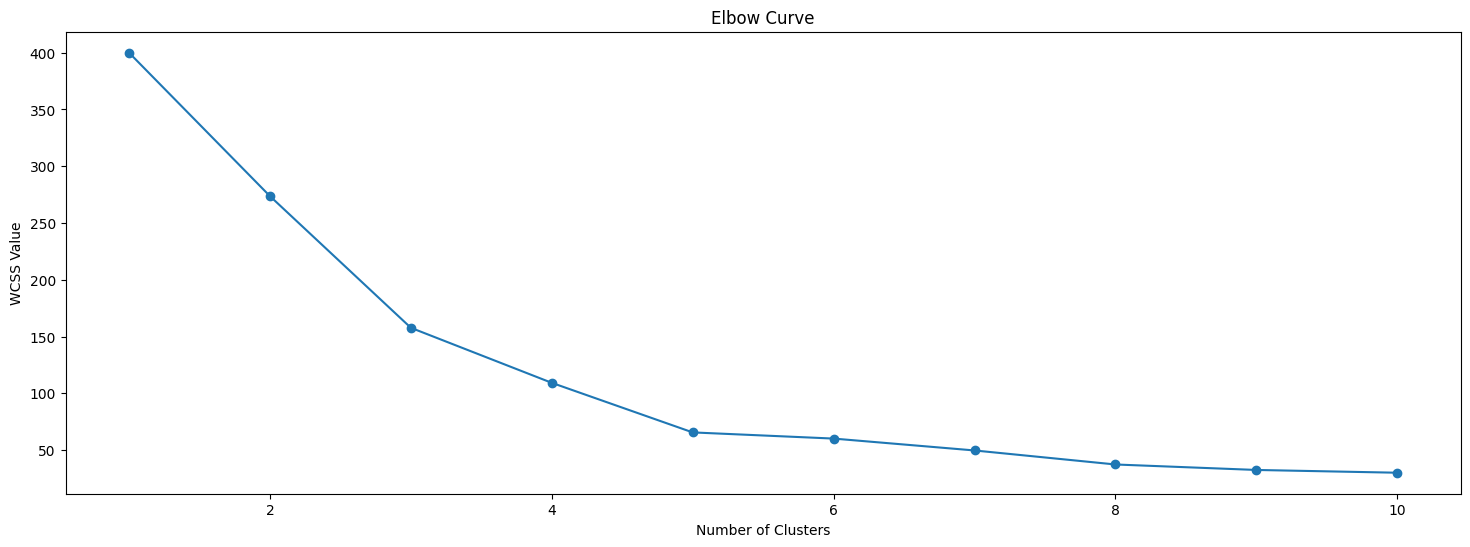

In [24]:
plt.figure(figsize=(18,6))
#### plot the elbow curve
plt.plot(range(1,11),wcss,marker='o')
#### give the title of the graph
plt.title("Elbow Curve")
#### depict the x axis
plt.xlabel("Number of Clusters")
#### depict the y axis
plt.ylabel("WCSS Value")
plt.show()

#### OBSERVATIONS:

1.  From the above graph, we can see that the WCSS curve that was rapidly decreasing, it suddenly became after K = 5.

2.  So the optimal number of clusters to be considered by K-Means Clustering Algorithm for this dataset is 5.

#### Step 10: Train the K-Means Model

In [25]:
#### Create an object for kmeans

kmeans = KMeans(
    n_clusters          =       5                       ,
    init                =       'k-means++'             ,
    random_state        =        42          
)


#### Train the K-Means model
kmeans.fit(X_scaled)

KMeans(n_clusters=5, random_state=42)

#### OBSERVATIONS:

(i.)    The object for k-means has been initialized with the help of the following parameters :----

        (a.)    n_clusters ===========>   Total number of clusters to be formed

        (b.)    init       ===========>   K-Means Centroid Initialization

        (c.)    random state ========>    ensures reproducibility

#### Step 11: Predict the K-Means Model

In [26]:
Y_means = kmeans.predict(X_scaled)

In [27]:
Y_means

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

#### OBSERVATIONS:

1.  The clusters have been predicted for an input test data.

#### Step 12: Add the Cluster Labels to the dataset

In [28]:
print("Length of the dataset is:", len(df))

Length of the dataset is: 200


In [29]:
print("Length of the Cluster Labels is:", len(Y_means))

Length of the Cluster Labels is: 200


In [30]:
df   ############  Independent features

,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [31]:
Y_means    ##########3  Ckuster Labels

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [32]:
#### Adding the Cluster Labels to the dataset

df['Cluster_Labels'] = Y_means

In [33]:
#### Display the dataset

df

,Gender,Age,Annual_Income,Spending_Score,Cluster_Labels
0,Male,19,15,39,4
1,Male,21,15,81,2
2,Female,20,16,6,4
3,Female,23,16,77,2
4,Female,31,17,40,4
...,...,...,...,...,...
195,Female,35,120,79,1
196,Female,45,126,28,3
197,Male,32,126,74,1
198,Male,32,137,18,3


#### OBSERVATIONS:

1.  The dataset has all the details of the Customers like as follows :-----

    (a.)    Gender ===============>  Gender of the customer 

    (b.)    Age    ===============>  Age    of the customer

    (c.)    Annual_Income =========>  Annual Income of the customer

    (d.)    Spending_Score ========>  Spending Score of the customer

    (e.)    Cluster_Labels =========>  Labels for the customers

####  Step 13: Visualize the Cluster Labels

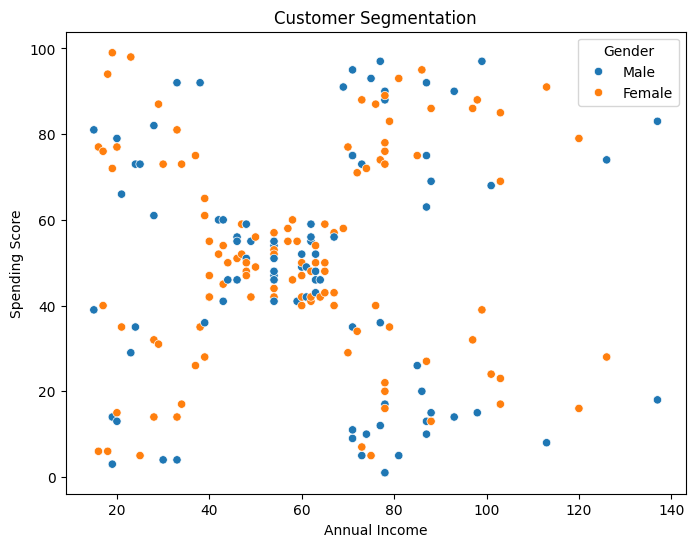

In [34]:
plt.figure(figsize=(8,6))

#### perform the scatterplot
sns.scatterplot(x=df['Annual_Income'], y=df['Spending_Score'],hue=df['Gender'])

#### Give the title of the graph
plt.title("Customer Segmentation")

#### Give the x label for the graph
plt.xlabel("Annual Income")

#### Give the y label for the graph
plt.ylabel("Spending Score")

#### Display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph depicts about the Customer Segmentation of Annual Income vs Spending Score for various Male and Feamle Customers.

2.  The above graph also explains about

        (a.)    Customers with high Annual income + high spending score

        (b.)    Customers with high Annual income + less spending score

        (c.)    Customers with low  Annual income + high spending score

        (d.)    Customers with low  Annual income + less spending score

3. In general, this graph explains about the customers reloationship for the Annual Income with respect to the Spending Scores.

#### Step 14: Work with the centroids

In [35]:
#### Get the centroids for all the clusters

centroids = kmeans.cluster_centers_

print("Centroids values for all the cluster is:", centroids)

Centroids values for all the cluster is: [[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


#### OBSERVATIONS:

1.  kmeans.cluster_centers_ =============>  obtains the centroid values for all the custers.

2.  But the centroid values are all in the scaled form.

3.  We need to convert the scaled form of the centroids to the original form.

In [36]:
original_centroids = sc.inverse_transform(centroids)

In [37]:
original_centroids

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

#### OBSERVATIONS:

1.  Here by using inverse_transform , we have obtained the original form of all the scaled values of the centroid.

#### Step 15: Plot the Centroids

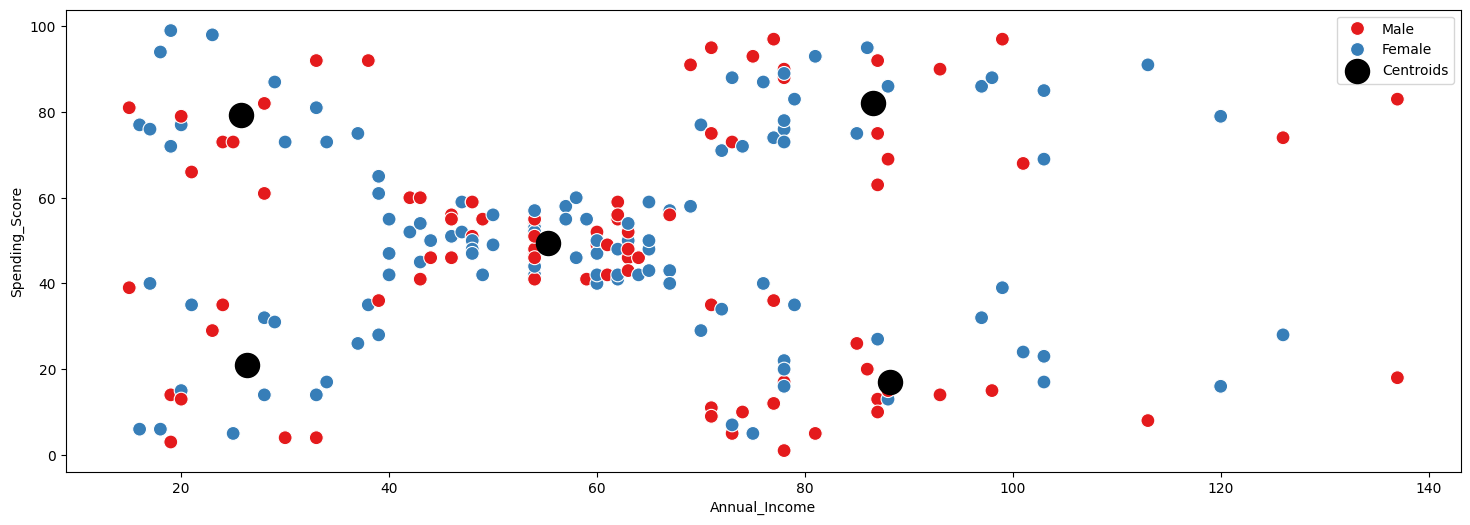

In [38]:
plt.figure(figsize=(18,6))

#### Plot the original data
sns.scatterplot(x=df['Annual_Income'],y=df['Spending_Score'], hue=df['Gender'],palette='Set1',s=100)

#### PLot the centroids
plt.scatter(
    original_centroids[:,0]                                                         ,
    original_centroids[:,1]                                                         ,
    s               =                       300                                     ,
    c               =                      'black'                                  ,
    marker          =                       'o'                                     ,
    label           =                      'Centroids'                              
)

### Plot the legends

plt.legend()

#### Display the graph
plt.show()

#### OBSERVATIONS:

1.  The above dataset explains about the customer details for the Annual_Income vs Spending_Score.

2.  There are a total of five clusters formed in the dataset.

3.  For each and every cluster, centroids are formed for each and every cluster.

#### Step 16:   Evaluate the Quality of Clustering

In [39]:
from sklearn.metrics    import  silhouette_score


score = silhouette_score(X_scaled, Y_means)

print("Silhouette Scores of the cluster is:", score)

Silhouette Scores of the cluster is: 0.5546571631111091


#### OBSERVATIONS:

1.  Here the Silhouette Score of the cluster is 0.5546. 

2.  The Silhouette Scoring of the cluster is 0.5546 which is a good clustering quality
 

#### Silhouette Scoring Interpretation:-------

 | Score       | Meaning              |
 | ----------- | -------------------- |
 | < 0.25      | Poor clustering      |
 | 0.25 – 0.50 | Average clustering   |
 | 0.50 – 0.70 | Good clustering      |
 | > 0.70      | Excellent clustering |
